<a href="https://colab.research.google.com/github/Hasini20062024/-online-exam-system/blob/master/Student_Performance_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
print("Libraries imported successfully")

Libraries imported successfully


In [235]:
np.random.seed(42)
num_students=2000
data = {
    'Student_ID': np.arange(1001, 1001 + num_students),
    'Gender': np.random.choice(['Male', 'Female'], num_students),
    'Department': np.random.choice(['CSE', 'IT', 'ECE', 'ME', 'CE'], num_students),
    'Attendance': np.random.randint(50, 100, num_students),
    'Study_Hours': np.random.randint(1, 12, num_students),
    'Assignments_Score': np.random.randint(40, 100, num_students),
    'Internal_Marks': np.random.randint(35, 100, num_students),
    'Projects_Completed': np.random.randint(0, 8, num_students),
    'Communication_Skills': np.random.randint(1, 10, num_students),
    'Technical_Skills': np.random.randint(1, 10, num_students),
    'Aptitude_Score': np.random.randint(40, 100, num_students),
    'Coding_Score': np.random.randint(35, 100, num_students),
    'Backlogs': np.random.randint(0, 6, num_students),
    'Internships': np.random.randint(0, 4, num_students),
    'Certifications': np.random.randint(0, 10, num_students),
    'Extracurricular_Activities': np.random.choice(
        ['Low', 'Medium', 'High'], num_students
    ),
    'Internet_Access': np.random.choice(['Yes', 'No'], num_students),
    'Placement_Status': np.random.choice(['Placed', 'Not Placed'], num_students)
}
df=pd.DataFrame(data)
print(df.head())

   Student_ID  Gender Department  Attendance  Study_Hours  Assignments_Score  \
0        1001    Male         ME          85            2                 41   
1        1002  Female        ECE          57            8                 58   
2        1003    Male         CE          69            7                 58   
3        1004    Male        CSE          81            8                 95   
4        1005    Male         CE          99            3                 46   

   Internal_Marks  Projects_Completed  Communication_Skills  Technical_Skills  \
0              57                   3                     3                 7   
1              98                   7                     2                 1   
2              54                   4                     7                 2   
3              50                   0                     5                 9   
4              51                   3                     5                 3   

   Aptitude_Score  Coding_Score 

In [236]:
print("Dataset Shape: ",df.shape)

Dataset Shape:  (2000, 18)


In [177]:
df.head(10)

,Student_ID,Gender,Department,Attendance,Study_Hours,Assignments_Score,Internal_Marks,Projects_Completed,Communication_Skills,Technical_Skills,Aptitude_Score,Coding_Score,Backlogs,Internships,Certifications,Extracurricular_Activities,Internet_Access,Placement_Status
0,1001,Male,ME,85,2,41,57,3,3,7,91,57,4,2,8,Low,No,Not Placed
1,1002,Female,ECE,57,8,58,98,7,2,1,89,67,4,0,3,High,Yes,Placed
2,1003,Male,CE,69,7,58,54,4,7,2,40,54,4,1,6,Medium,Yes,Not Placed
3,1004,Male,CSE,81,8,95,50,0,5,9,99,59,0,2,0,Low,No,Not Placed
4,1005,Male,CE,99,3,46,51,3,5,3,42,86,1,2,1,High,Yes,Placed
5,1006,Female,CSE,63,7,93,53,2,5,6,54,46,2,1,6,High,No,Placed
6,1007,Male,IT,99,10,81,42,5,7,7,91,66,0,1,1,Medium,Yes,Not Placed
7,1008,Male,CSE,77,9,81,72,6,9,9,49,67,2,1,5,High,Yes,Not Placed
8,1009,Male,ME,95,3,98,72,4,8,5,60,49,4,1,9,Low,Yes,Placed
9,1010,Female,ECE,73,10,59,87,5,6,4,76,85,2,3,8,High,Yes,Placed


In [178]:
df.tail(10)

,Student_ID,Gender,Department,Attendance,Study_Hours,Assignments_Score,Internal_Marks,Projects_Completed,Communication_Skills,Technical_Skills,Aptitude_Score,Coding_Score,Backlogs,Internships,Certifications,Extracurricular_Activities,Internet_Access,Placement_Status
1990,2991,Female,CE,51,8,72,61,0,6,9,47,41,0,1,6,Medium,Yes,Placed
1991,2992,Male,CE,80,7,85,58,6,4,2,72,95,5,1,2,High,No,Placed
1992,2993,Male,ECE,52,7,56,73,6,5,8,80,99,5,0,3,Low,No,Placed
1993,2994,Male,CE,57,6,81,52,0,2,3,58,40,1,1,1,High,Yes,Not Placed
1994,2995,Male,ECE,73,3,51,79,6,8,1,60,58,2,2,4,Low,Yes,Placed
1995,2996,Male,CSE,64,5,87,46,1,7,1,80,71,1,1,8,Medium,No,Placed
1996,2997,Female,CSE,92,1,85,83,6,6,2,60,79,5,2,8,Low,Yes,Placed
1997,2998,Male,CSE,80,7,66,65,3,7,7,64,85,2,3,6,Low,No,Not Placed
1998,2999,Male,IT,58,9,87,56,6,1,6,81,79,4,2,7,Medium,Yes,Not Placed
1999,3000,Male,IT,88,1,47,78,7,5,2,95,97,3,3,4,Medium,Yes,Not Placed


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Student_ID                  2000 non-null   int64 
 1   Gender                      2000 non-null   object
 2   Department                  2000 non-null   object
 3   Attendance                  2000 non-null   int64 
 4   Study_Hours                 2000 non-null   int64 
 5   Assignments_Score           2000 non-null   int64 
 6   Internal_Marks              2000 non-null   int64 
 7   Projects_Completed          2000 non-null   int64 
 8   Communication_Skills        2000 non-null   int64 
 9   Technical_Skills            2000 non-null   int64 
 10  Aptitude_Score              2000 non-null   int64 
 11  Coding_Score                2000 non-null   int64 
 12  Backlogs                    2000 non-null   int64 
 13  Internships                 2000 non-null   int6

In [180]:
df.describe()

,Student_ID,Attendance,Study_Hours,Assignments_Score,Internal_Marks,Projects_Completed,Communication_Skills,Technical_Skills,Aptitude_Score,Coding_Score,Backlogs,Internships,Certifications
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2000.500000,74.824500,6.050500,69.336500,67.485000,3.631000,5.012000,4.895000,69.635500,66.983500,2.482500,1.505500,4.385500
std,577.494589,14.385659,3.139407,17.254133,18.951025,2.273857,2.560495,2.564813,17.433405,19.021728,1.700335,1.141762,2.823451
min,1001.000000,50.000000,1.000000,40.000000,35.000000,0.000000,1.000000,1.000000,40.000000,35.000000,0.000000,0.000000,0.000000
25%,1500.750000,62.750000,3.000000,54.000000,51.000000,2.000000,3.000000,3.000000,54.000000,50.000000,1.000000,0.000000,2.000000
50%,2000.500000,75.000000,6.000000,69.000000,67.000000,4.000000,5.000000,5.000000,70.000000,67.000000,2.000000,1.000000,4.000000
75%,2500.250000,87.000000,9.000000,84.000000,84.250000,6.000000,7.000000,7.000000,85.000000,84.000000,4.000000,3.000000,7.000000
max,3000.000000,99.000000,11.000000,99.000000,99.000000,7.000000,9.000000,9.000000,99.000000,99.000000,5.000000,3.000000,9.000000


In [239]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

le = LabelEncoder()
df['Department'] = le.fit_transform(df['Department'])

le = LabelEncoder()
df['Extracurricular_Activities'] = le.fit_transform(df['Extracurricular_Activities'])

le = LabelEncoder()
df['Internet_Access'] = le.fit_transform(df['Internet_Access'])

le = LabelEncoder()
df['Placement_status'] = le.fit_transform(df['Placement_Status'])


In [240]:
X=df.drop('Placement_Status',axis=1)
y=df['Placement_Status']
print(X.head())
print(y.head())

   Student_ID  Gender  Department  Attendance  Study_Hours  Assignments_Score  \
0        1001       1           4          85            2                 41   
1        1002       0           2          57            8                 58   
2        1003       1           0          69            7                 58   
3        1004       1           1          81            8                 95   
4        1005       1           0          99            3                 46   

   Internal_Marks  Projects_Completed  Communication_Skills  Technical_Skills  \
0              57                   3                     3                 7   
1              98                   7                     2                 1   
2              54                   4                     7                 2   
3              50                   0                     5                 9   
4              51                   3                     5                 3   

   Aptitude_Score  Coding_

In [185]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("y_train shape: ",y_train.shape)
print("y_test shape: ",y_test.shape)

X_train shape:  (1600, 18)
X_test shape:  (400, 18)
y_train shape:  (1600,)
y_test shape:  (400,)


In [186]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)

X_train shape:  (1600, 18)
X_test shape:  (400, 18)


In [187]:
lr_model=LogisticRegression()
lr_model.fit(X_train,y_train)
print('Model trained succesfully')

Model trained succesfully


In [188]:
lr_predictions=lr_model.predict(X_test)
print(lr_predictions)

['Placed' 'Not Placed' 'Placed' 'Not Placed' 'Placed' 'Not Placed'
 'Not Placed' 'Not Placed' 'Placed' 'Not Placed' 'Not Placed' 'Not Placed'
 'Not Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Placed' 'Placed' 'Not Placed' 'Placed' 'Placed' 'Placed' 'Not Placed'
 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Not Placed' 'Placed' 'Not Placed' 'Not Placed' 'Placed' 'Not Placed'
 'Not Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Not Placed' 'Placed' 'Not Placed' 'Placed' 'Placed' 'Placed' 'Placed'
 'Placed' 'Not Placed' 'Placed' 'Placed' 'Placed' 'Not Placed' 'Placed'
 'Not Placed' 'Not Placed' 'Placed' 'Not Placed' 'Not Placed' 'Placed'
 'Placed' 'Not Placed' 'Not Placed' 'Placed' 'Not Placed' 'Not Placed'
 'Placed' 'Not Placed' 'Not Placed' 'Not Placed' 'Placed' 'Not Placed'
 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Placed' 'Not Placed'
 'Placed' 'Placed' 'Not Placed' 'Not Placed' 'Not Placed' 'Not Placed'
 'Not Placed'

In [189]:
lr_accuracy=accuracy_score(y_test,lr_predictions)
print("Accuracy: ",lr_accuracy)

Accuracy:  1.0


In [190]:
lr_confusionmatrix=confusion_matrix(y_test,lr_predictions)
print("Confusion Matrix: ")
print(lr_confusionmatrix)

Confusion Matrix: 
[[193   0]
 [  0 207]]


In [191]:
print(classification_report(y_test,lr_predictions))

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       193
      Placed       1.00      1.00      1.00       207

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [229]:
df_model=DecisionTreeClassifier(random_state=42)
df_model.fit(X_train,y_train)
df_predictions=df_model.predict(X_test)
df_accuracy=accuracy_score(y_test,df_predictions)
print("Accuracy: ",df_accuracy)


Accuracy:  1.0


In [228]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
rf_predictions=rf_model.predict(X_test)
rf_accuracy=accuracy_score(y_test,rf_predictions)
print("Accuracy: ",rf_accuracy)

Accuracy:  1.0


In [230]:
models=['Logistic Regression','Decision Tree','Random Forest']
accuracies=[lr_accuracy,df_accuracy,rf_accuracy]
comparison_df=pd.DataFrame({'Model':models,'Accuracy':accuracies})
print(comparison_df)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0


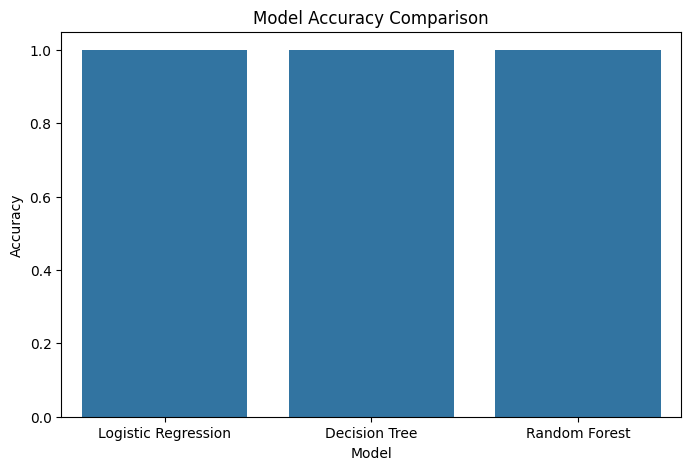

In [195]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model',y='Accuracy',data=comparison_df)
plt.title('Model Accuracy Comparison')
plt.show()

In [196]:
print(df['Placement_Status'].value_counts())

Placement_Status
Placed        1035
Not Placed     965
Name: count, dtype: int64


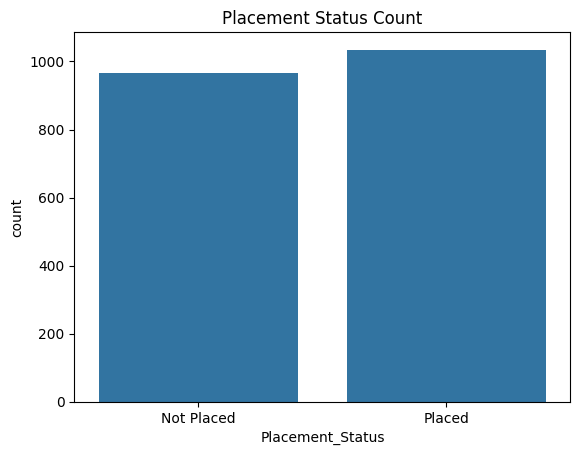

In [197]:
sns.countplot(data=df,x='Placement_Status')
plt.title('Placement Status Count')
plt.show()

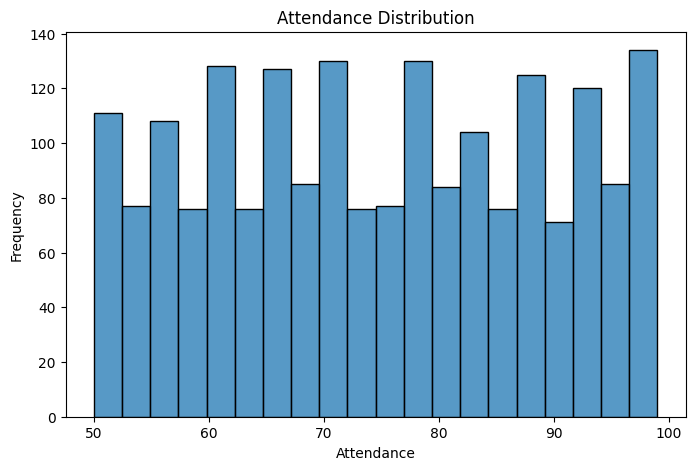

In [231]:
plt.figure(figsize=(8,5))
sns.histplot(df['Attendance'],bins=20)
plt.title('Attendance Distribution')
plt.xlabel('Attendance')
plt.ylabel('Frequency')
plt.show()

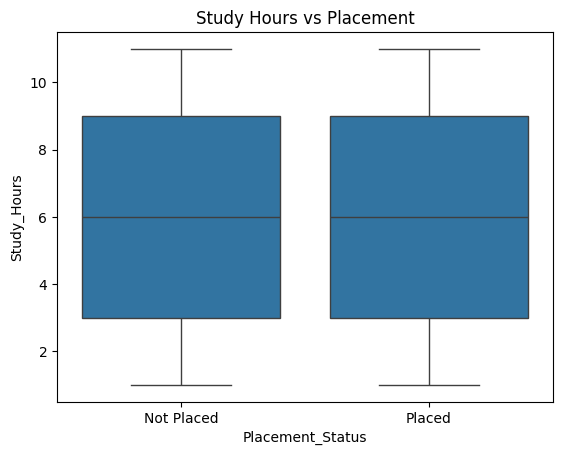

In [232]:
sns.boxplot(x='Placement_Status',y='Study_Hours',data=df)
plt.title('Study Hours vs Placement')
plt.show()

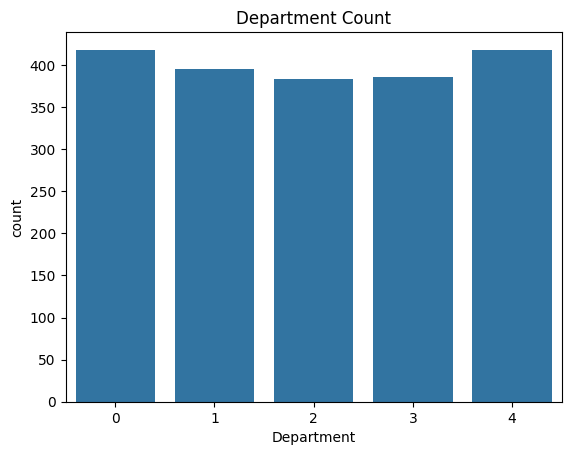

In [198]:
sns.countplot(data=df,x='Department')
plt.title('Department Count')
plt.show()

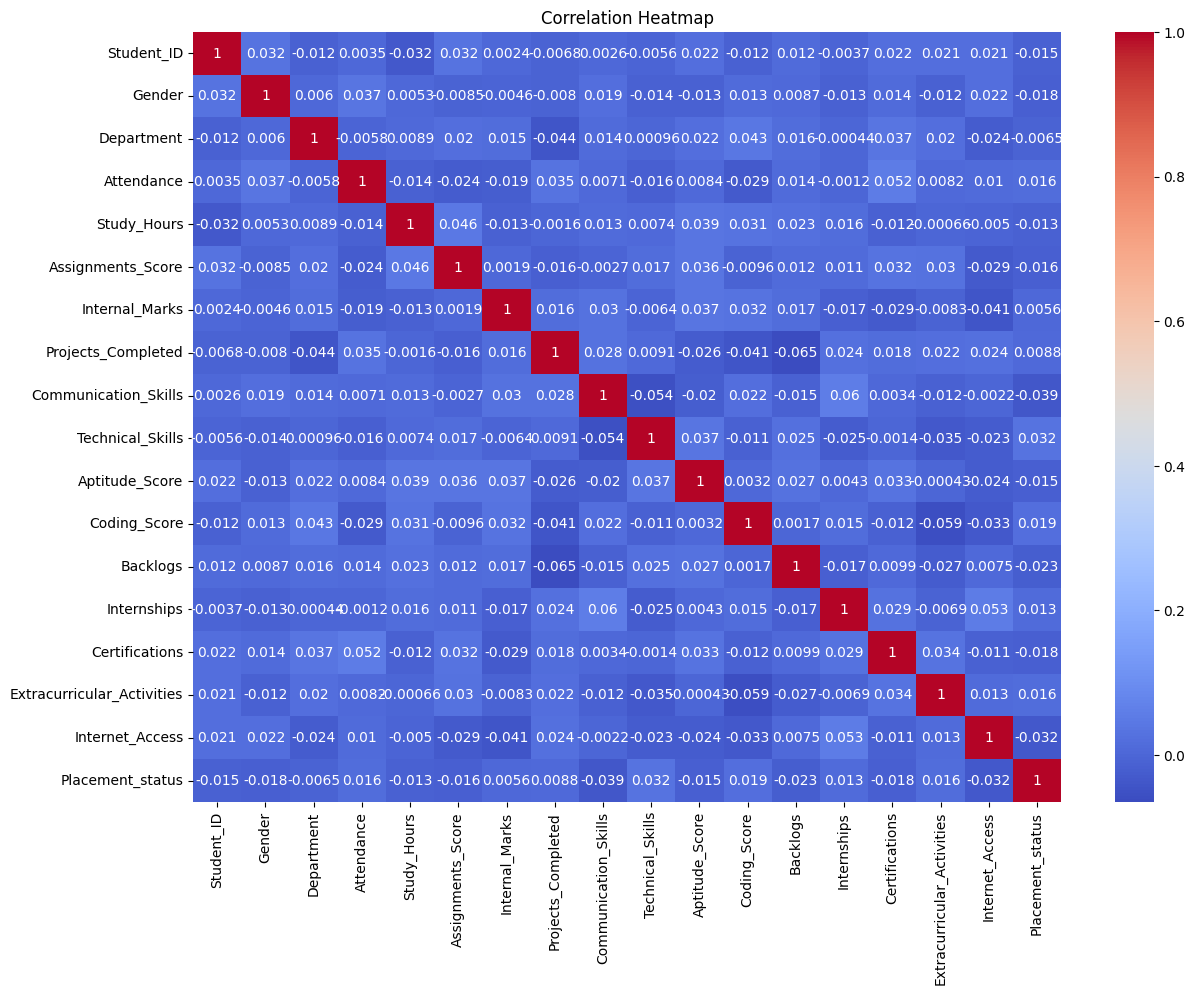

In [233]:
numeric_df=df.select_dtypes(include=['int64'])
corr=numeric_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [199]:
topstudents=df.sort_values(by='Coding_Score',ascending=False).head(10)
print(topstudents)

      Student_ID  Gender  Department  Attendance  Study_Hours  \
1501        2502       0           3          89            2   
395         1396       0           3          76            3   
740         1741       1           0          75            9   
739         1740       0           0          71            2   
1908        2909       0           4          66            4   
1388        2389       1           4          79            2   
444         1445       0           0          90            6   
1343        2344       1           2          67            7   
1330        2331       0           0          70            9   
489         1490       1           2          64            9   

      Assignments_Score  Internal_Marks  Projects_Completed  \
1501                 89              40                   1   
395                  65              95                   0   
740                  57              57                   5   
739                  80         

In [200]:
backlogs=df[df['Backlogs']>0]
backlogs.head()

,Student_ID,Gender,Department,Attendance,Study_Hours,Assignments_Score,Internal_Marks,Projects_Completed,Communication_Skills,Technical_Skills,Aptitude_Score,Coding_Score,Backlogs,Internships,Certifications,Extracurricular_Activities,Internet_Access,Placement_Status,Placement_status
0,1001,1,4,85,2,41,57,3,3,7,91,57,4,2,8,1,0,Not Placed,0
1,1002,0,2,57,8,58,98,7,2,1,89,67,4,0,3,0,1,Placed,1
2,1003,1,0,69,7,58,54,4,7,2,40,54,4,1,6,2,1,Not Placed,0
4,1005,1,0,99,3,46,51,3,5,3,42,86,1,2,1,0,1,Placed,1
5,1006,0,1,63,7,93,53,2,5,6,54,46,2,1,6,0,0,Placed,1


In [201]:
print('avg attendance: ',df['Attendance'].mean())

avg attendance:  74.8245


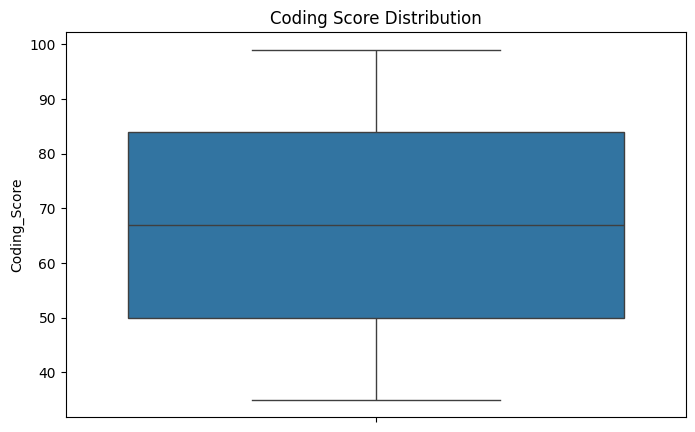

In [202]:
plt.figure(figsize=(8,5))
sns.boxplot(df['Coding_Score'])
plt.title('Coding Score Distribution')
plt.show()

In [207]:
df['Total_Score']=(df['Assignments_Score']+df['Internal_Marks']+df['Coding_Score'])/3
print(df[['Total_Score']].head())

   Total_Score
0    51.666667
1    74.333333
2    55.333333
3    68.000000
4    61.000000


In [208]:
df['skill_index']=(df['Technical_Skills']+df['Communication_Skills'])/2
print(df[['skill_index']].head())

   skill_index
0          5.0
1          1.5
2          4.5
3          7.0
4          4.0


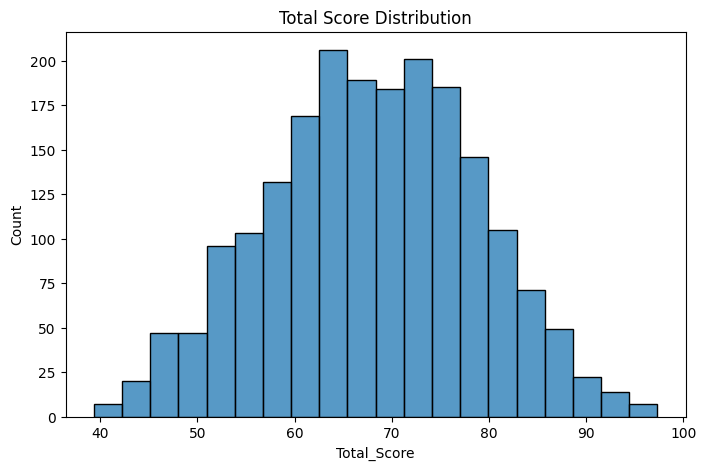

In [209]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Score'],bins=20)
plt.title('Total Score Distribution')
plt.show()

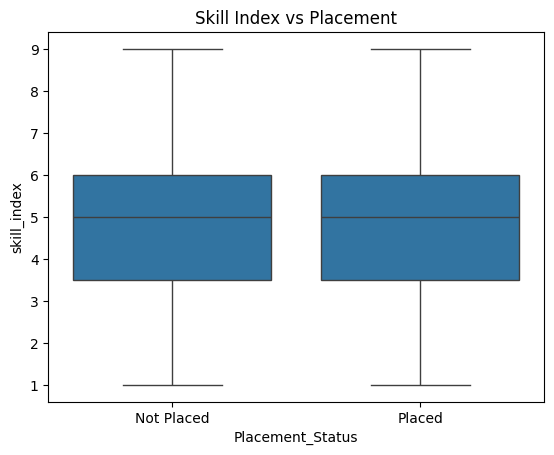

In [210]:
sns.boxplot(x='Placement_Status',y='skill_index',data=df)
plt.title('Skill Index vs Placement')
plt.show()

In [211]:
weak_students=df.sort_values(by='Total_Score',ascending=True).head(10)
print(weak_students)

      Student_ID  Gender  Department  Attendance  Study_Hours  \
685         1686       0           1          68            8   
1144        2145       0           0          74            2   
777         1778       0           0          75            6   
1652        2653       0           0          92           10   
1649        2650       0           2          79           10   
351         1352       1           4          78            1   
1167        2168       0           4          72            2   
1862        2863       1           0          89            8   
1172        2173       1           0          85            8   
24          1025       0           0          60            7   

      Assignments_Score  Internal_Marks  Projects_Completed  \
685                  42              35                   3   
1144                 41              37                   1   
777                  41              40                   4   
1652                 44         

In [212]:
df['Academic_strength']=(df['Attendance']+df['Study_Hours']+df['Assignments_Score'])/3
print(df[['Academic_strength']].head())

   Academic_strength
0          42.666667
1          41.000000
2          44.666667
3          61.333333
4          49.333333


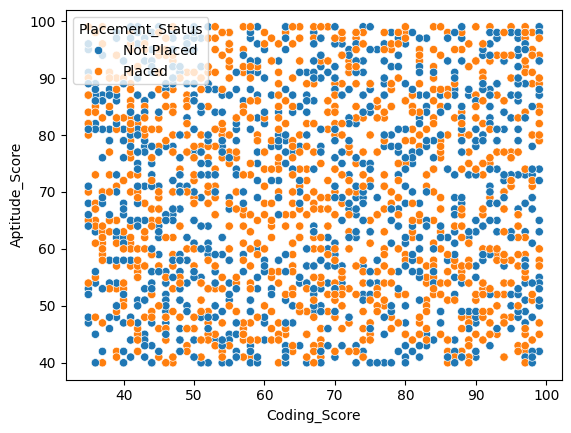

In [213]:
sns.scatterplot(
    x='Coding_Score',
    y='Aptitude_Score',
    hue='Placement_Status',
    data=df
)
plt.show()

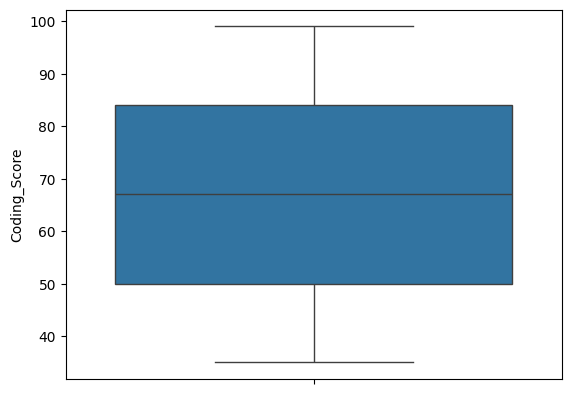

In [214]:
sns.boxplot(df['Coding_Score'])
plt.show()

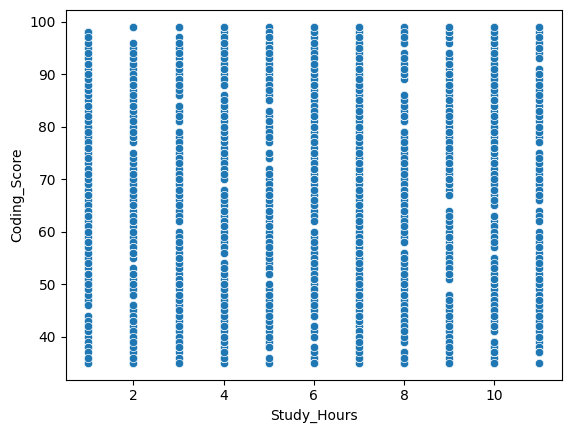

In [215]:
sns.scatterplot(x='Study_Hours',y='Coding_Score',data=df)
plt.show()

In [25]:
def generate_recommendations(student_id):
  recommendations=[]
  if student_id['Coding_Score']<50:
    recommendations.append('Improve coding skills')
  if student_id['Attendance']<65:
    recommendations.append('Practice coding daily')
  if student_id['Communication_Skills']<5:
    recommendations.append('Improve communication skills')
  if student_id['Study_Hours']<3:
    recommendations.append('Increase study hours')
  if len(recommendations)==0:
    recommendations.append('Performance is good')
  return recommendations

In [216]:
df['recommendations']=df.apply(generate_recommendations,axis=1)
print(df[['recommendations']].head())

                                     recommendations
0  [Improve communication skills, Increase study ...
1  [Practice coding daily, Improve communication ...
2                              [Performance is good]
3                              [Performance is good]
4                              [Performance is good]


In [217]:
param_grid={
   'n_estimators':[50,100],
   'max_depth':[3,5,10]
}

In [218]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3
)
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)

{'max_depth': 3, 'n_estimators': 50}


In [70]:
best_model=grid_search.best_estimator_
final_predictions=best_model.predict(X_test)
final_accuracy=accuracy_score(y_test,final_predictions)
print("Final Accuracy: ",final_accuracy)

Final Accuracy:  1.0


In [219]:
print(X_train.columns)

Index(['Student_ID', 'Gender', 'Department', 'Attendance', 'Study_Hours',
       'Assignments_Score', 'Internal_Marks', 'Projects_Completed',
       'Communication_Skills', 'Technical_Skills', 'Aptitude_Score',
       'Coding_Score', 'Backlogs', 'Internships', 'Certifications',
       'Extracurricular_Activities', 'Internet_Access', 'Placement_status'],
      dtype='object')


In [242]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [243]:
print(best_model.n_features_in_)

18


In [245]:
student_data=[[
      1001,
      1,
     2,
      85,
     6,
      80,
     78,
   3,
     7,
     8,
     82,
     80,
  0,
     1,
    5,
      1,
     1,
    1
    ]]
student_data=scaler.transform(student_data)
final_prediction=best_model.predict(student_data)
if final_prediction[0]==1:
  print('Likely Placed')
else:
  print('Needs Improvement')

Needs Improvement


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [249]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 1.0
